# KdV PINN

Notebook for studying and testing training

### Preamble

In [ ]:
# Add parent directory to path for imports
import sys
sys.path.insert(0, '..')

In [ ]:
%load_ext autoreload
%autoreload 2

import torch
from models import KdV_pinn
from scattering import ScatteringData, SchrodingerSolver
from train import train_pinn, pretrain
from sampling import sample_bulk
from configuration import kdv_config, config_to_dict, dict_to_config
from plot_utils import plot_field_visualization
from physics import kdv
import numpy as np

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using {device} device.")

Using mps device.


### Load and modify configuration

In [2]:
training_config = kdv_config
training_config.num_epochs = 500
training_config.num_pretrain_epochs = 200
training_config.num_samp_bulk = 64
training_config.num_samp_eval = 128
training_config.plot_interval = 50
training_config.MLP = [2, 128, 128, 128, 1]
training_config.kappas = [1]
training_config.x0s = [2]
training_config.lr = 1e-3
training_config.T = 1
training_config.L = 8
# training_config.Lmax = 0.5*( 4. * training_config.kappas[0]**2 * training_config.T - training_config.x0s[0])
training_config.Lmax = 2
training_config.lambda_BC = 1
training_config.lambda_kdv = 1
training_config.vmin = 0
training_config.vmax = 3
torch.manual_seed(training_config.seed)
# training_config.kappas = [2.0, 1.9, 1.8, 1.7, 1.6, 1.5]
# training_config.x0s =[20.0, 19.0, 18.0, 17.0, 16.0, 15.0]
print(f"Lmax = {training_config.Lmax}")

Lmax = 2


### Load and train model
Plots updated interactively

## Analytic field visualization

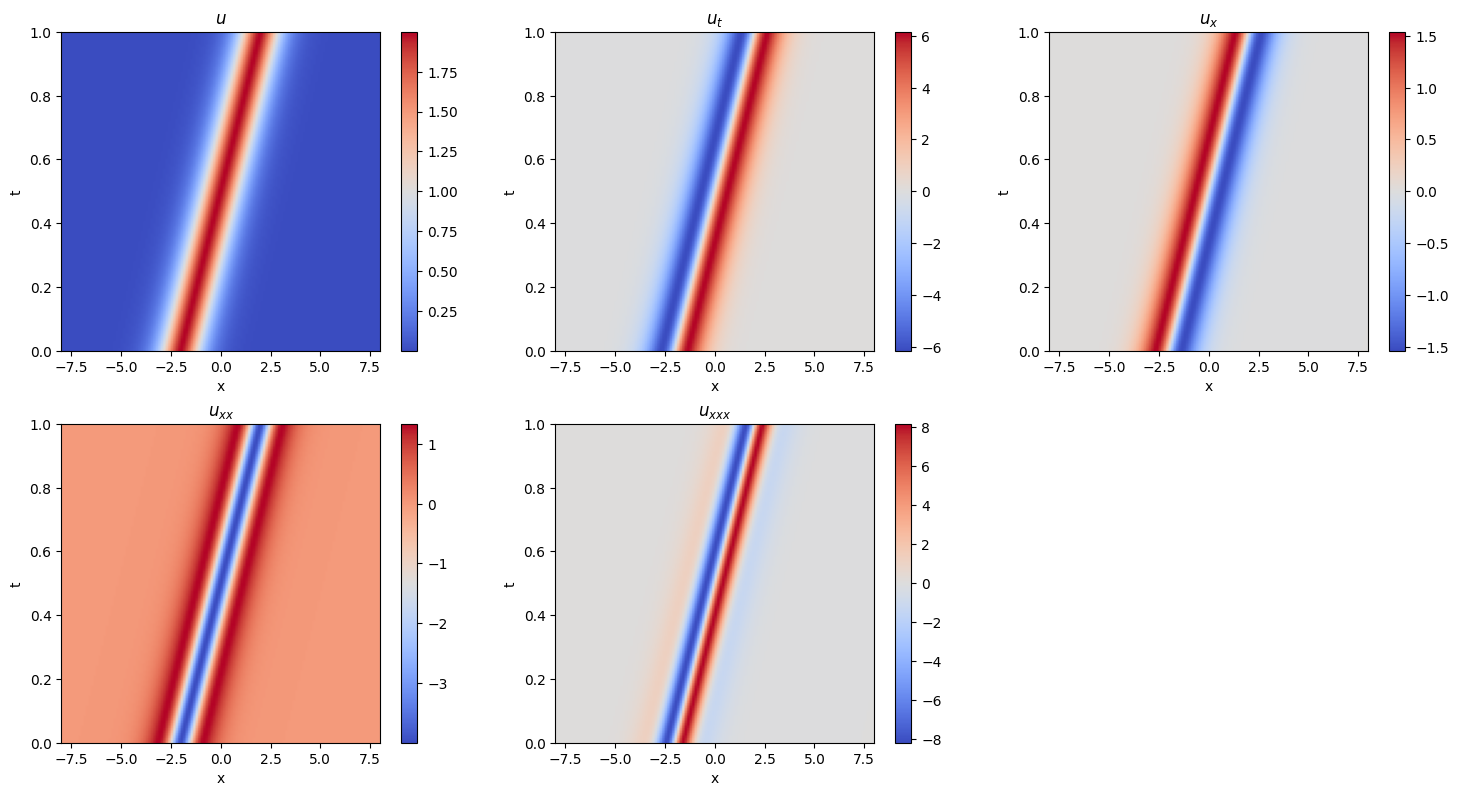

In [3]:
sd = ScatteringData(training_config.kappas, training_config.x0s, R=None, use_tau=True)
input_eval = sample_bulk(training_config, resample=False, num_samp=128).to(device)
input_eval.requires_grad_(True)
t = input_eval[:, 0:1]
x = input_eval[:, 1:2]
u_ana = sd.u(x, t)
results_ana = kdv(u_ana, input_eval)
plot_field_visualization(results_ana, training_config, 'deriv')

## Pretraining

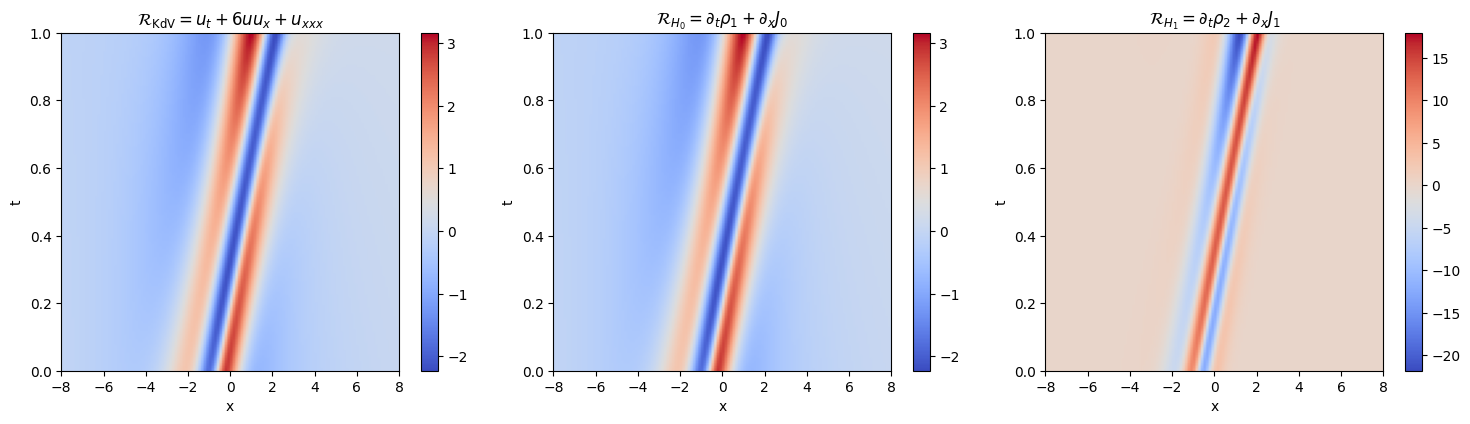

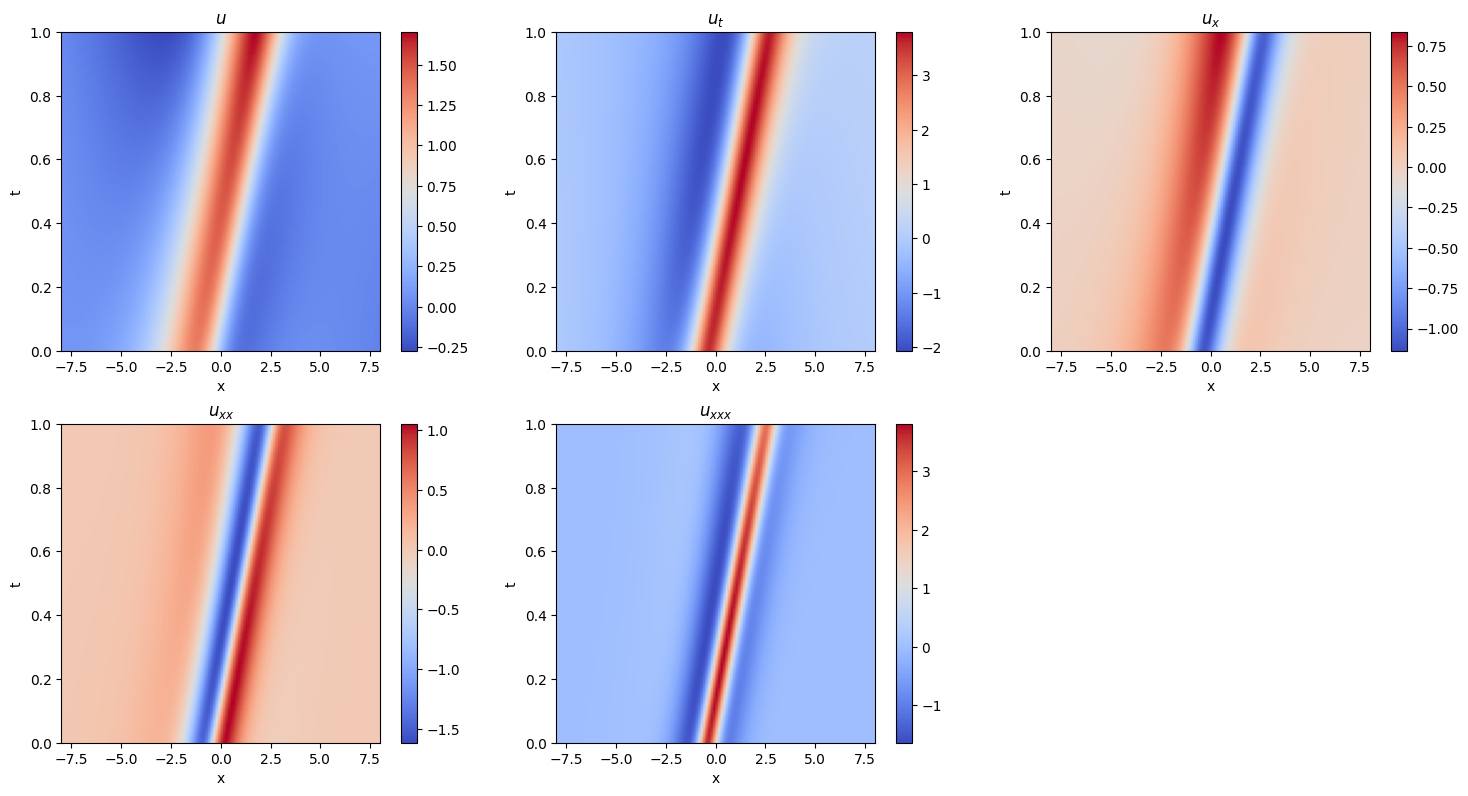

In [4]:
model = KdV_pinn(training_config).to(device)
pretrain(model, sd.forward_fcn, training_config, device, num_epochs=training_config.num_pretrain_epochs)

u0 = model(input_eval)
results0 = kdv(u0, input_eval)
plot_field_visualization(results0, training_config, 'res')
plot_field_visualization(results0, training_config, 'deriv')

## Training the PINN

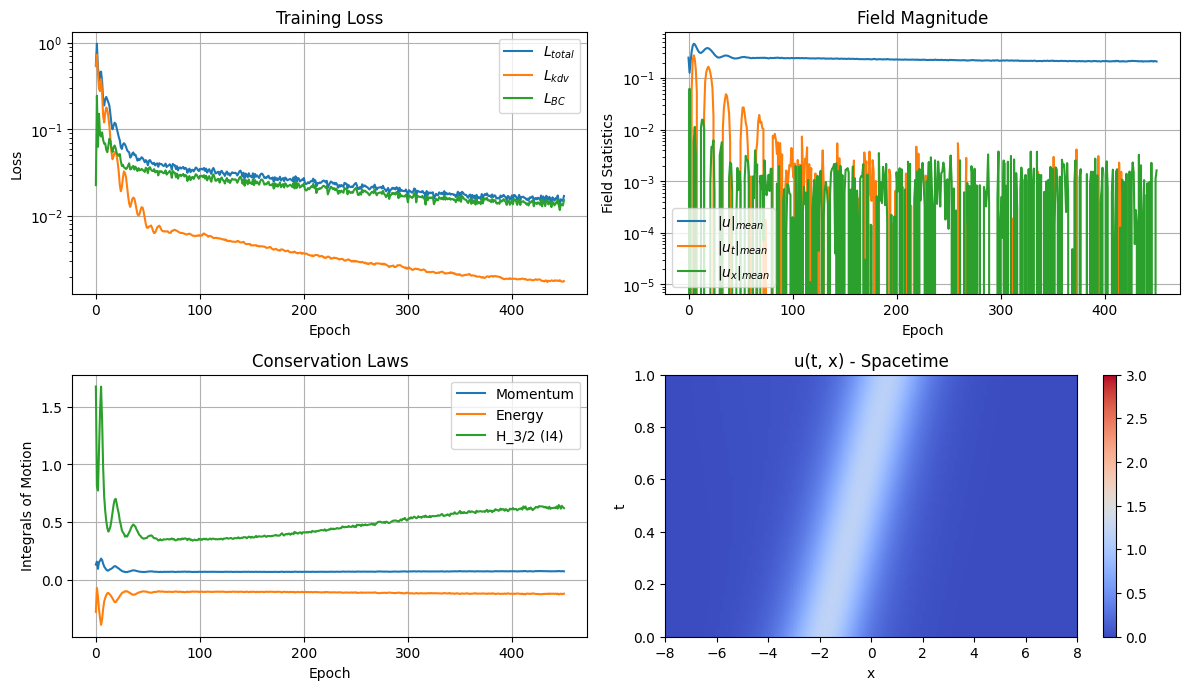

Training complete!


In [5]:
result = train_pinn(model, training_config, device, interactive=True)
print("Training complete!")

### Save Model

In [6]:
torch.save({
    'model_state_dict': result['model'].state_dict(),
    'optimizer_state_dict': result['optimizer'].state_dict(),
    'config': config_to_dict(training_config),
    'metrics': result['metrics']
}, 'pinn_model.pt')
print("Model saved to pinn_model.pt")

Model saved to pinn_model.pt


### Load Model

In [7]:
checkpoint = torch.load('pinn_model.pt')
loaded_config = dict_to_config(checkpoint['config'])
loaded_model = KdV_pinn(loaded_config).to(device)
loaded_model.load_state_dict(checkpoint['model_state_dict'])
print("Model loaded successfully!")

Model loaded successfully!


In [8]:
input_eval = sample_bulk(training_config, resample=False, num_samp=128).to(device)
input_eval.requires_grad_(True)
u = model(input_eval)
results = kdv(u, input_eval)

## Compare to Analytic results

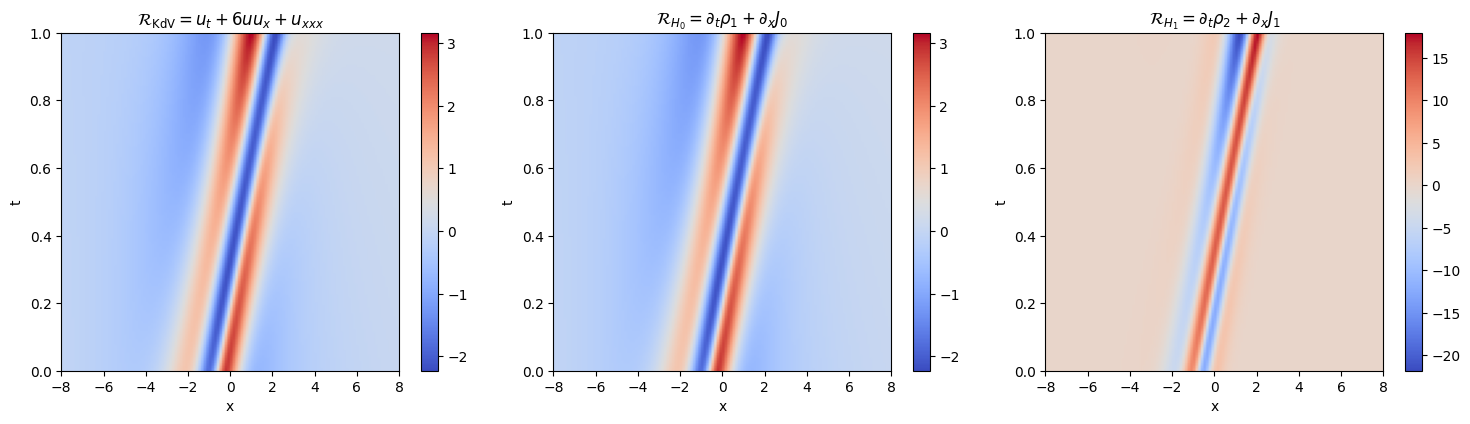

In [9]:
delta = {k : (results0[k] - results_ana[k]) for k in results}
plot_field_visualization(delta, training_config, 'res')

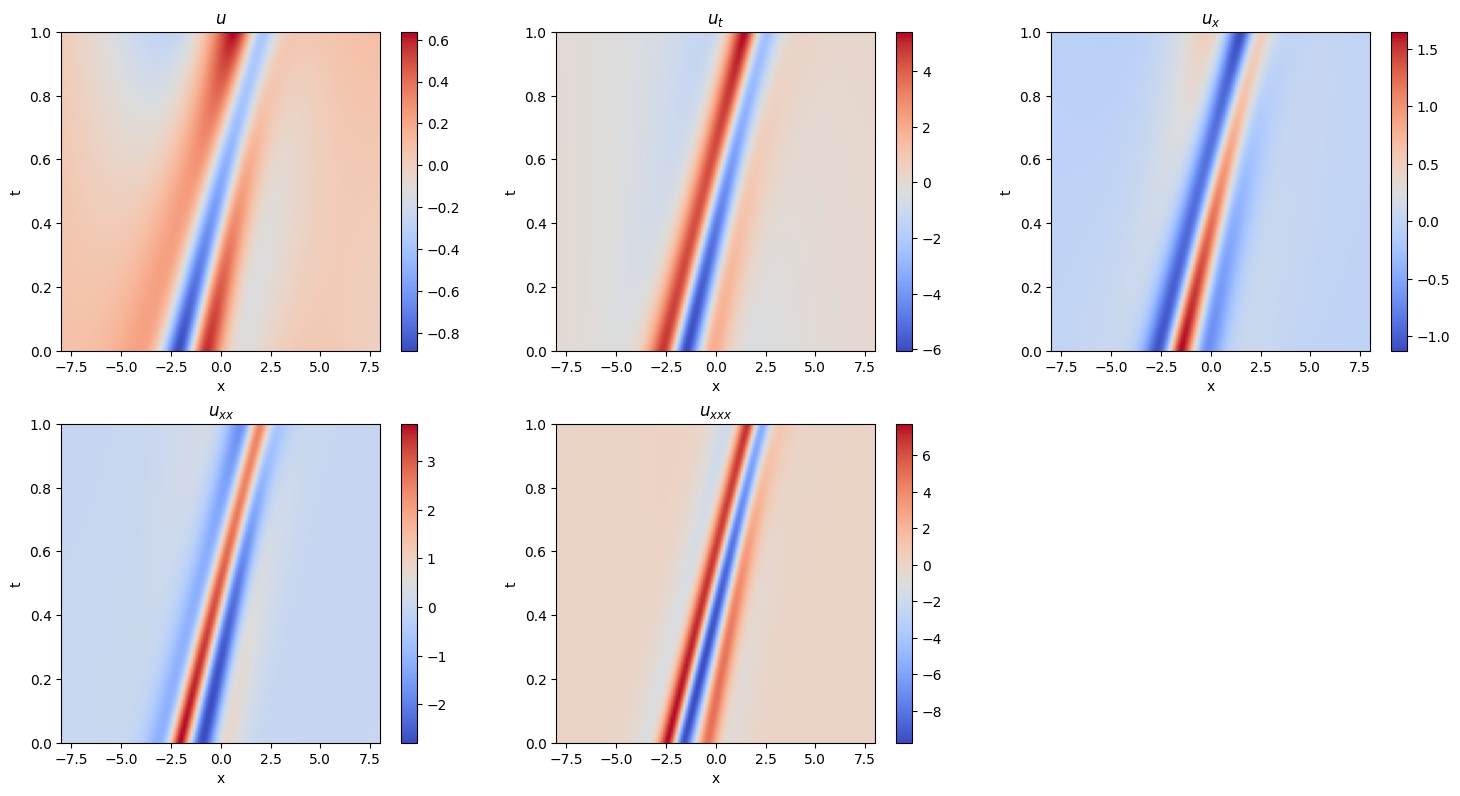

In [10]:
plot_field_visualization(delta, training_config, 'deriv')

## Results
### Field Residuals

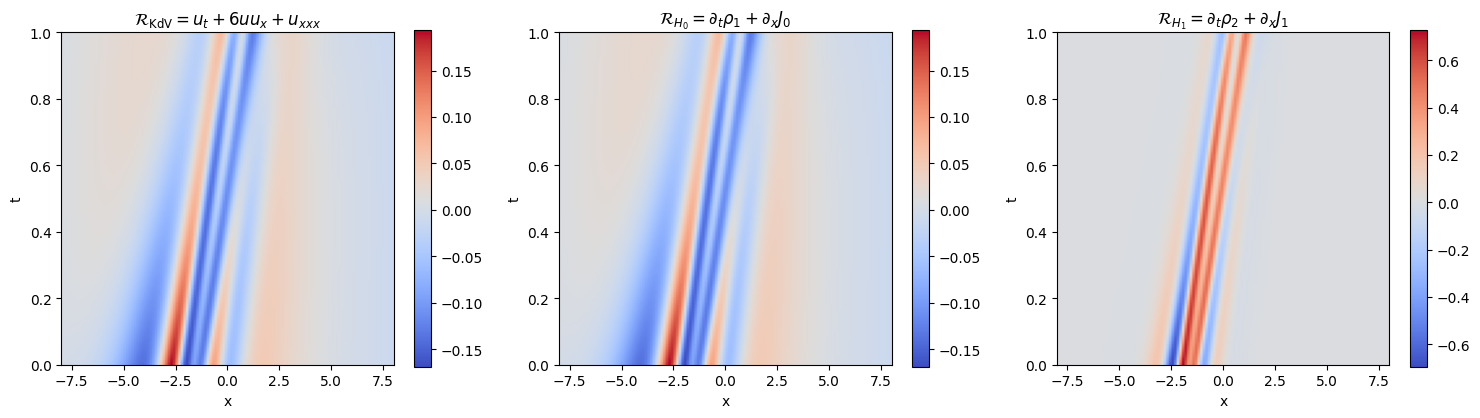

In [11]:
plot_field_visualization(results, training_config, 'res')

### Field Derivatives

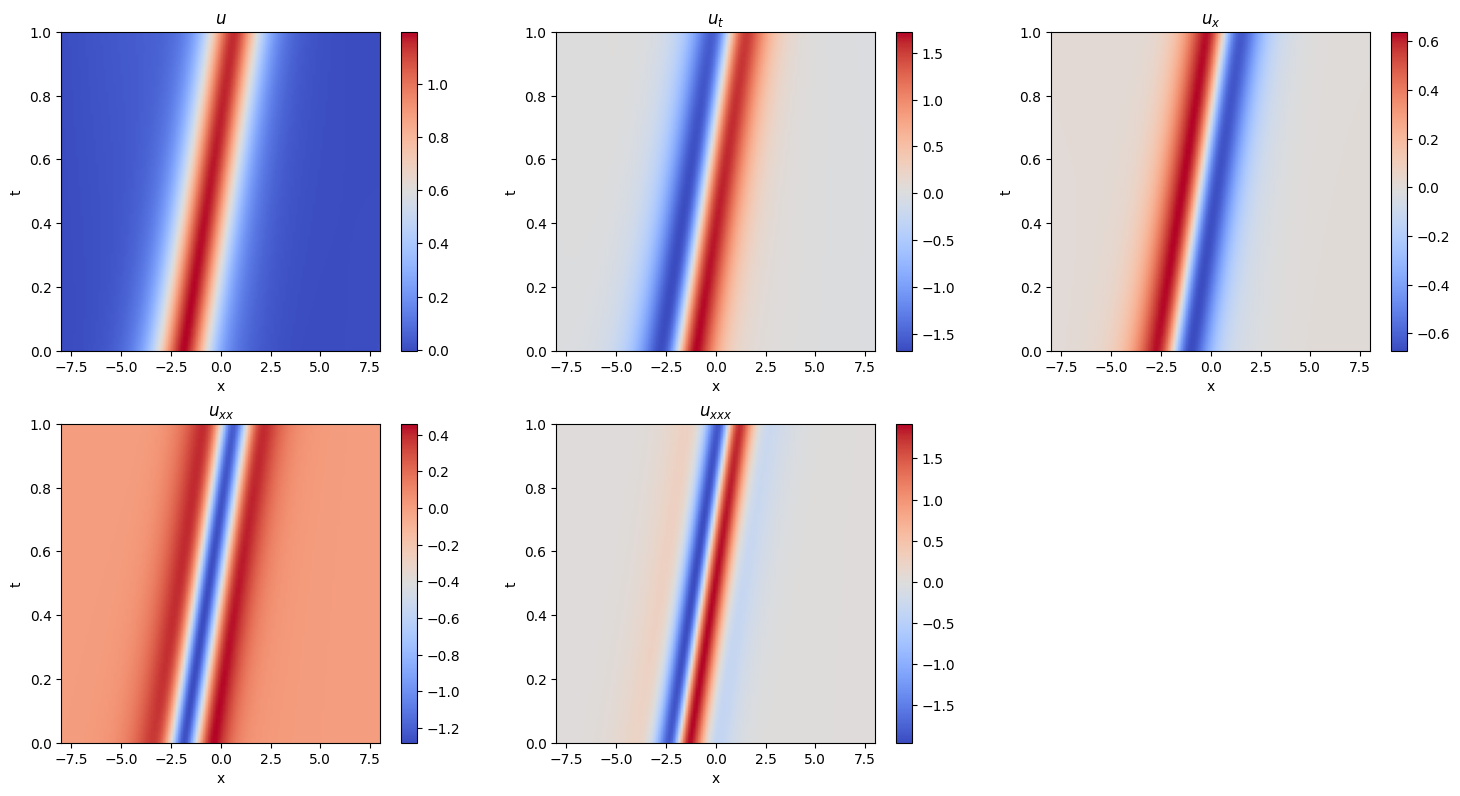

In [12]:
plot_field_visualization(results, training_config, 'deriv')

### Integrals of Motion

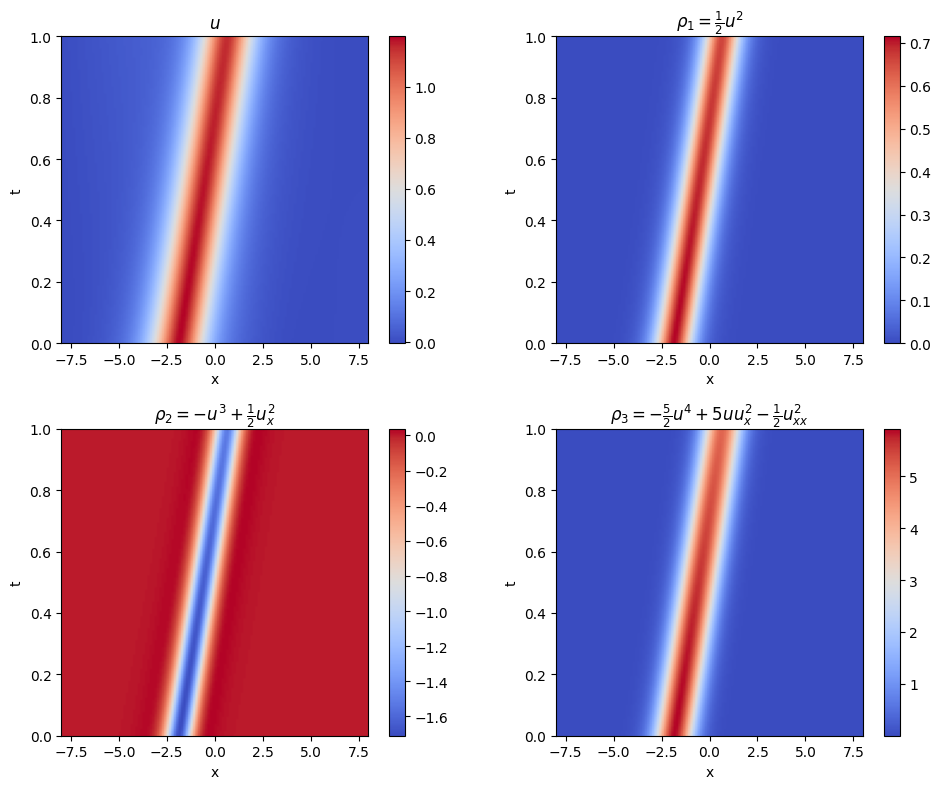

In [13]:
plot_field_visualization(results, training_config, 'iom')

### Conservation Currents

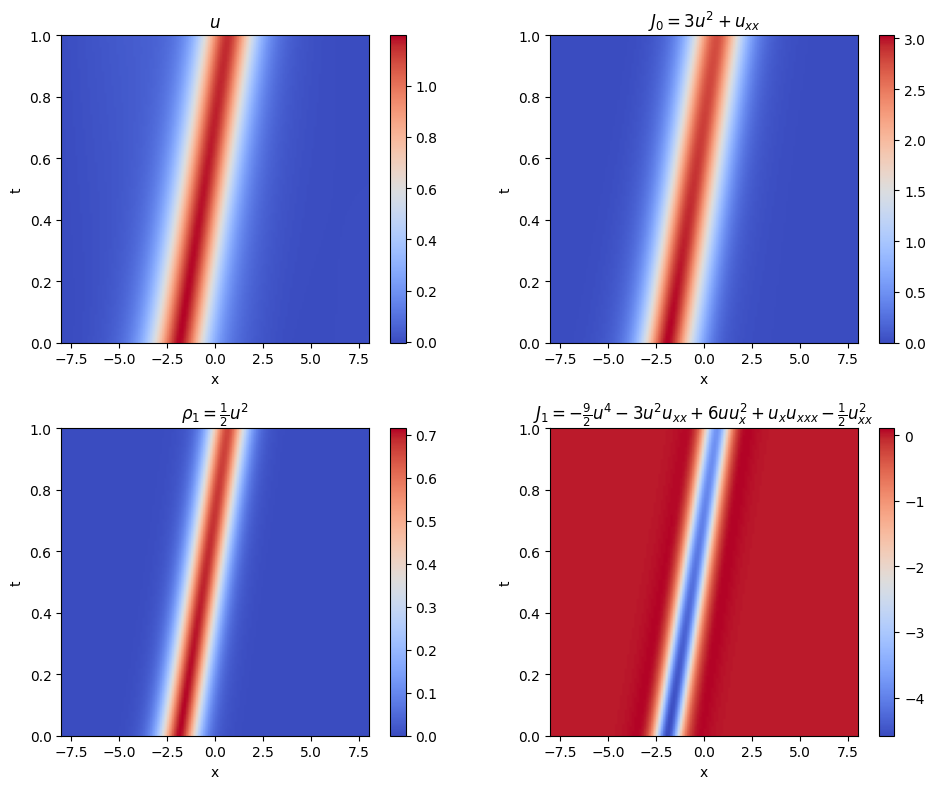

In [14]:
plot_field_visualization(results, training_config, 'curr')

## Lax Formulation and Eigenvalues of the Schrodinger Operator

In [15]:
u_reshape = u.reshape(training_config.num_samp_eval, training_config.num_samp_eval).detach().cpu().numpy()
tvals = t.reshape(training_config.num_samp_eval, training_config.num_samp_eval).detach().cpu().numpy()[:, 0]
x_d = x.detach().reshape(training_config.num_samp_eval,training_config.num_samp_eval)[0, :].cpu().numpy()
dx = x_d[1] - x_d[0]
u_reshape.shape

(128, 128)

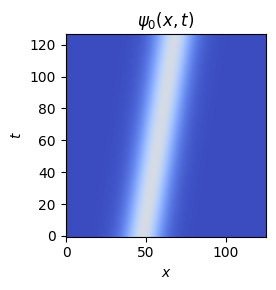

In [16]:
S = SchrodingerSolver()
eigenvector_stack, eigenvalue_stack = S.solve(u_reshape, dx)
kappa_rec = np.sqrt(-eigenvalue_stack[:,:sd.Ns] + 1e-8)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, sd.Ns, figsize=(12,3))
if sd.Ns == 1:
    axes = [axes]
for ev_idx in range(sd.Ns):
    kap = kappa_rec[ev_idx]
    eigenvector_timeseries = eigenvector_stack[:, :, ev_idx]
    eigenvector_timeseries = eigenvector_timeseries**2
    axes[ev_idx].imshow(eigenvector_timeseries, 
                        vmin=0, vmax=0.1,
                        origin='lower', cmap='coolwarm')
                        
    axes[ev_idx].set_xlabel('$x$')
    axes[ev_idx].set_ylabel('$t$')
    axes[ev_idx].set_title('$\\psi_{' + str(ev_idx) + '}(x,t)$')
plt.tight_layout()
plt.show()


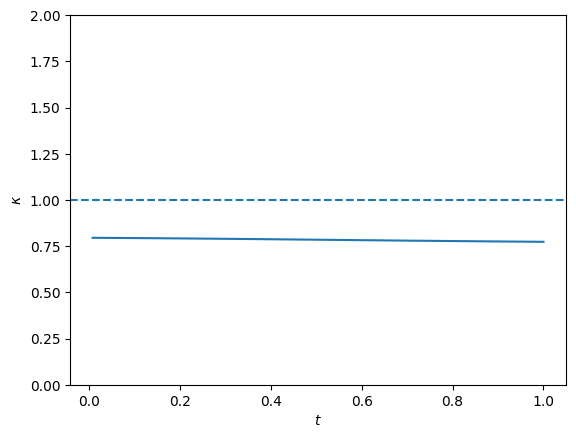

<Figure size 640x480 with 0 Axes>

In [17]:

ax = plt.subplot()
for idx in range(sd.Ns):
    line, = ax.plot(tvals[1:], kappa_rec[:, idx])
    ax.axhline(sd.kappas[idx], color=line.get_color(), linestyle='--')
    ax.set_ylim(0,2)
    ax.set_ylabel("$\\kappa$")
    ax.set_xlabel("$t$")
# plt.legend()
plt.show()
plt.tight_layout()